# Hw 5 problem 1
Below is the python notebook from the in-class demonstration in Lec 12.
Your task for this problem is the following:
1. change the training labels from binary classification to *multiclass* classification with $K= 3$ classes.
2. change the binary cross entropy loss to the (standard) cross entropy.
3. your plot should demonstrate that the objective function is still convex.

In [14]:
import numpy as np

In [15]:
n = 20
X = np.random.randn( n , 2 )
w_true = np.random.randn(2)
y = np.sign(X @ w_true)
# random training dataset

def logistic_regression_obj(w):
    return np.log( 1 + np.exp ( y * (X @ w)) ).mean()

In [16]:
# theta becomes w in this notebook
w1 = np.random.randn(2)
w2 = np.random.randn(2)
logistic_regression_obj(w1)

np.float64(1.0813956632144648)

In [17]:
import matplotlib.pyplot as plt

In [18]:
# now our goal is to create all w's in the line segment
# between w1 and w2
c_list = np.linspace(0,1)
w_list = [ c * w1 + (1-c) * w2 for c in c_list ]
obj_list = [ logistic_regression_obj(w) for w in w_list ]

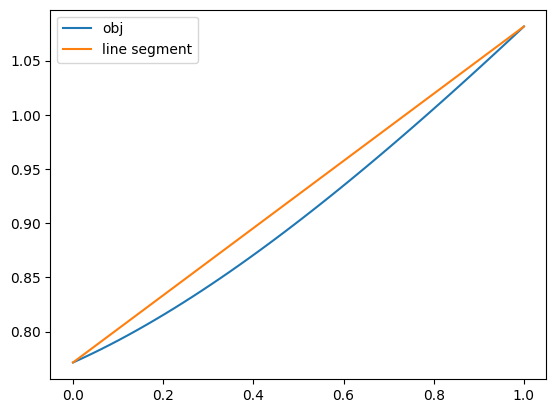

In [19]:
plt.plot(c_list, obj_list, label = 'obj')
plt.plot([0,1], [obj_list[0], obj_list[-1]], label='line segment')
plt.legend()

# My answer

### Generate a synthetic dataset with K = 3 classes

In [20]:
np.random.seed(0)

n = 60
d = 2
K = 3

X = np.random.randn(n, d)

# create true weight matrix, one column per class
W_true = np.random.randn(d, K)

# compute softmax probabilities to generate labels
logits = X @ W_true
exp_logits = np.exp(logits)
probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)

y = np.array([np.random.choice(K, p=probs[i]) for i in range(n)])


### Multiclass softmax cross entropy objective

In [21]:
def softmax_cross_entropy(W):
    logits = X @ W
    exp_logits = np.exp(logits)
    P = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    loss = -np.log(P[np.arange(n), y]).mean()
    return loss


### Create two random parameter matrices W1 and W2

In [22]:
W1 = np.random.randn(d, K)
W2 = np.random.randn(d, K)


### Evaluate convexity along the segment c W1 + (1 c) W2

In [23]:
c_list = np.linspace(0, 1, 50)

W_list = [c * W1 + (1.0 - c) * W2 for c in c_list]
obj_list = [softmax_cross_entropy(W) for W in W_list]


### Plot objective value and the straight line segment

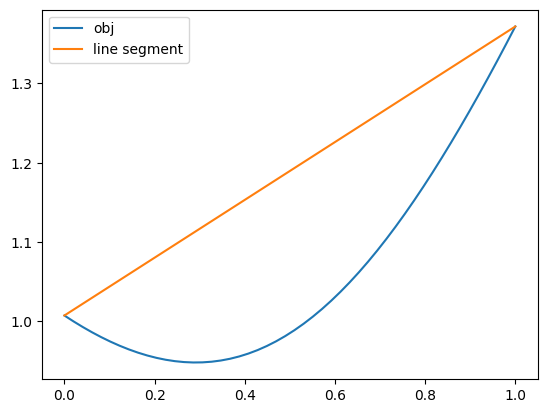

In [25]:
plt.plot(c_list, obj_list, label = 'obj')
plt.plot([0,1], [obj_list[0], obj_list[-1]], label='line segment')
plt.legend()
